In [1]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
messages = pd.read_csv(r"C:\Users\ayush\Downloads\spam_cleaned.csv")
messages.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 🧹 Text Preprocessing Steps for SMS Spam Detection

## 1️⃣ Stopwords Removal

**Stopwords** are common words that appear very frequently in text but carry little meaningful information for prediction.

### Examples
- is
- am
- are
- the
- a
- an
- and

### Why Remove Them?
✅ Reduces vocabulary size

✅ Removes noise from the dataset

✅ Improves model efficiency

### Example

**Before:**  I am going to the market
**After:**   going market

## 2️⃣ Stemming

**Stemming** is the process of reducing words to their root form.

### Examples

| Original Word | Stemmed Word |
|--------------|-------------|
| Play | Play |
| Playing | Play |
| Played | Play |
| Player | Play |

### Why Perform Stemming?

✅ Reduces vocabulary size

✅ Groups similar words together

✅ Improves model generalization

Without stemming, each variation would occupy a separate position in the vocabulary.

---

## 3️⃣ Removing Numbers and Special Characters

### Code

```python
review = re.sub('[^a-zA-Z]', ' ', review)

Purpose

This statement removes:

Numbers
Punctuation marks
Special characters

ex : Win ₹5000 now!!! Call 9876543210 to only Win now Call


## 4️⃣ Converting Text to Lowercase

## review = review.lower()

✅ Reduces vocabulary size

✅ Improves consistency



In [2]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []

for i in range(0 , len(messages)):
     review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
     review = review.lower()
     review = review.split()
     
     review = [ps.stem(word) for word in review if not word in stopwords.words("english")]
     review = " ".join(review)
     corpus.append(review)

## 5️⃣ Converting Text into Numerical Features (Bag of Words)

### Code

```python
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
x = cv.fit_transform(corpus).toarray()

x.shape
```

### What is CountVectorizer?

Machine Learning algorithms cannot understand text directly. Therefore, we convert text into numerical features.

**CountVectorizer** creates a **Bag of Words (BoW)** representation by counting the occurrence of each word in every message.

### Example

Suppose the corpus contains:

```text
I love AI
AI is amazing
I love Machine Learning
```

The vocabulary created will be:

| Word |
|--------|
| ai |
| amazing |
| learning |
| love |
| machine |

The transformed matrix becomes:

| Message | ai | amazing | learning | love | machine |
|-----------|----|---------|---------|------|---------|
| I love AI | 1 | 0 | 0 | 1 | 0 |
| AI is amazing | 1 | 1 | 0 | 0 | 0 |
| I love Machine Learning | 0 | 0 | 1 | 1 | 1 |

### Explanation of Code

#### `cv = CountVectorizer()`

Creates a CountVectorizer object that will build the vocabulary from the corpus.

#### `cv.fit_transform(corpus)`

- **fit()** → Learns all unique words from the corpus.
- **transform()** → Converts each message into a numerical vector based on word counts.

#### `.toarray()`

Converts the sparse matrix into a NumPy array for easier viewing and processing.

### Why Use CountVectorizer?

✅ Converts text into numerical format

✅ Creates feature vectors for machine learning models

✅ Represents each message using word frequencies

---

### Understanding `x.shape`

```python
x.shape
```

Returns:

```python
(number_of_messages, number_of_unique_words)
```

For example:

```python
(5572, 6296)
```

This means:

- **5572** → Total SMS messages (rows)
- **6296** → Unique words in the vocabulary (columns)

### Summary

| Step | Purpose |
|--------|----------|
| CountVectorizer() | Create Bag of Words model |
| fit() | Learn vocabulary |
| transform() | Convert text to vectors |
| toarray() | Convert sparse matrix to NumPy array |
| x.shape | View dataset dimensions |

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(corpus).toarray()
x.shape

(5572, 6221)

In [4]:
y = messages["target"].map({"ham":0 , "spam":1})

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Gaussian Naive Bayes": GaussianNB(),
    "SVC": SVC()
}

# We will create a generic function to check each model's performance so that we can compare those

In [6]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    

    models_list = []
    scores = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test,y_pred)
        
        model_name = list(models.keys())[i]
        print(f'---- score for --- {model_name} ----')
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    
    print()
    
    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores        
    return report

In [7]:
report = evaluate_models(x, y, models)

---- score for --- Multinomial Naive Bayes ----
0.9739910313901345
---- score for --- Gaussian Naive Bayes ----
0.862780269058296
---- score for --- SVC ----
0.9775784753363229



In [8]:
report.sort_values('Score')

,Model_name,Score
1,Gaussian Naive Bayes,0.862780
0,Multinomial Naive Bayes,0.973991
2,SVC,0.977578


# Support Vector Classifier achieved the highest accuracy among all evaluated models.Therefore, it was selected as the final model for hyperparameter tuning and deployment.

## Hyperparameter Tuning using GridSearchCV and LinearSVC

### Objective

After comparing multiple machine learning algorithms, **Linear Support Vector Classifier (LinearSVC)** achieved the best performance. To further improve the model, **GridSearchCV** is used to find the optimal value of the hyperparameter **C**.

---

### What is Hyperparameter Tuning?

Hyperparameters are parameters that are set before training a machine learning model. The performance of a model can vary significantly depending on these values.

**GridSearchCV** systematically tests different combinations of hyperparameters and selects the one that produces the highest cross-validation accuracy.

---

### Why LinearSVC?

LinearSVC is particularly effective for text classification tasks because:

✅ Works well with high-dimensional sparse data

✅ Faster than traditional SVC on text datasets

✅ Handles large vocabularies efficiently

✅ Provides excellent performance for spam detection problems

---

### Hyperparameter Being Tuned

| Parameter | Description |
|------------|------------|
| C | Controls the trade-off between maximizing the margin and minimizing classification errors |

### Values Tested

```python
C = [0.01, 0.1, 1, 10]
```

A smaller value of **C** creates a wider margin and allows more misclassifications, while a larger value attempts to classify all training samples correctly.

---

### Cross Validation

```python
cv = 5
```

The training dataset is divided into 5 folds:

1. Train on 4 folds
2. Validate on 1 fold
3. Repeat 5 times
4. Calculate the average accuracy

This provides a more reliable estimate of model performance.

---

### Workflow

1. Create a LinearSVC model.
2. Define a grid of hyperparameter values.
3. Perform 5-Fold Cross Validation.
4. Evaluate every parameter combination.
5. Select the parameter set with the highest accuracy.

---

### Outputs

```python
svc_cv.best_params_
```

Returns the best value of **C**.

```python
svc_cv.best_score_
```

Returns the highest cross-validation accuracy achieved by the model.

---

### Conclusion

GridSearchCV helps identify the optimal hyperparameters for LinearSVC, resulting in a more accurate and robust SMS Spam Detection model.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [10]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10]
}

svc_cv = GridSearchCV(LinearSVC(),params,cv=5,scoring='accuracy',n_jobs=-1)

svc_cv.fit(X_train, y_train)

print("Best Parameters:", svc_cv.best_params_)
print("Best Accuracy:", svc_cv.best_score_)

Best Parameters: {'C': 1}
Best Accuracy: 0.9833944829460524


In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

spam_detect_model = LinearSVC(**svc_cv.best_params_)

spam_detect_model.fit(X_train, y_train)

y_pred = spam_detect_model.predict(X_test)

confusion_m = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the model is {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{confusion_m}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of the model is 0.9776

Confusion Matrix:
[[962   3]
 [ 22 128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



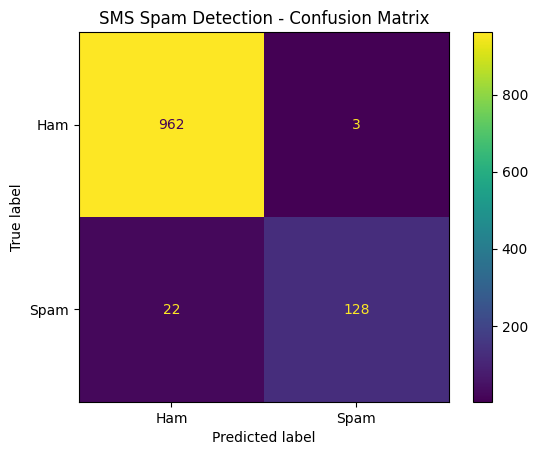

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Ham', 'Spam'],
    values_format='d'
)

plt.title("SMS Spam Detection - Confusion Matrix")
plt.show()

# Conclusion

The SMS Spam Detection model was successfully built using Natural Language Processing and Machine Learning techniques.

Key Results:
- Text preprocessing performed using stopword removal and stemming.
- CountVectorizer used for feature extraction.
- Multiple models compared.
- LinearSVC achieved the best performance.
- Final Accuracy: 97.76%

The model can effectively classify SMS messages as Spam or Ham.